# Final Python Notebook 3 — Ensemble Classifier & Regression Decision Trees

---

**Author Name:** Mathushihan Rathnatheepan

**Student ID:** 20232274/w2120253

**Module Name:** 5DATA002W.2 Machine Learning & Data Mining

**Date:** April 2025

---

**Peer Review Information**

* **Peer Reviewer Name:** Kriththigan Satkunam
* **Date of Review:** 01/04/2026
* **Session:** Code Peer-Review Meeting 3 (Week 10)

**Tests Checked by Peer Reviewer:**
1. Voting ensemble classifier combines exactly TWO base learners (LR and KNN) correctly
2. DT-1 (fully grown) and DT-2 (pruned to 4 levels) both train successfully
3. All three regression metrics (MSE, MAE, R²) are calculated and displayed correctly

---

## PART 1: VOTING ENSEMBLE CLASSIFIER FOR LOAN APPROVAL STATUS

**Requirement:** Combine TWO out of THREE base learners (NB, LR, KNN) into a probability-based voting ensemble

**Base Learners Chosen:** Logistic Regression (LR) + K-Nearest Neighbours (KNN)

**Justification:** These were the two best-performing models from Notebook 2

---

**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Import all necessary libraries for ensemble classification and regression

In [1]:
# pandas for data handling
import pandas as pd

# numpy for numerical operations
import numpy as np

# matplotlib for visualizations
import matplotlib.pyplot as plt
import matplotlib
# Using Colab/Jupyter inline display so plots appear inside notebook cells
# matplotlib.use('Agg')
%matplotlib inline

# import the TWO base learners we're using: Logistic Regression and KNN
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# VotingClassifier to combine the two base learners
from sklearn.ensemble import VotingClassifier

# decision tree regressor for Part 2
from sklearn.tree import DecisionTreeRegressor, plot_tree

# train-test split
from sklearn.model_selection import train_test_split

# StandardScaler for feature normalization (needed for LR and KNN)
from sklearn.preprocessing import StandardScaler

# classification metrics
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay)

# regression metrics: MSE, MAE, R² (as per coursework requirements)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# suppress warnings
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Load Dataset A (Classification) and prepare train-test split

In [2]:
# load Dataset A — same dataset used in Notebook 2
df_classification = pd.read_csv('Dataset_A_Classification.csv')

# separate features and target
X = df_classification.drop(columns=['loan_approval_status'])
y = df_classification['loan_approval_status']

# perform train-test split with same configuration as Notebook 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# apply scaling for LR and KNN (both require scaled features)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Dataset loaded: {df_classification.shape}')
print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')

Dataset loaded: (58642, 19)
Training set: 46913 rows
Test set:     11729 rows


**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Train and evaluate BASE LEARNER 1 - Logistic Regression

In [3]:
# create and train Logistic Regression (BASE LEARNER 1)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)

# generate predictions
y_pred_lr = lr_model.predict(X_test_sc)
y_prob_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print('=== BASE LEARNER 1: Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Approved (0)', 'Rejected (1)']))

# calculate metrics
lr_accuracy  = accuracy_score(y_test, y_pred_lr)
lr_recall    = recall_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_f1        = f1_score(y_test, y_pred_lr)
lr_auc       = roc_auc_score(y_test, y_prob_lr)

print(f'Accuracy:  {lr_accuracy:.4f}')
print(f'Recall:    {lr_recall:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'F1-Score:  {lr_f1:.4f}')
print(f'AUC-ROC:   {lr_auc:.4f}')

=== BASE LEARNER 1: Logistic Regression ===
              precision    recall  f1-score   support

Approved (0)       0.91      0.97      0.94     10059
Rejected (1)       0.74      0.43      0.54      1670

    accuracy                           0.90     11729
   macro avg       0.82      0.70      0.74     11729
weighted avg       0.89      0.90      0.88     11729

Accuracy:  0.8968
Recall:    0.4269
Precision: 0.7381
F1-Score:  0.5410
AUC-ROC:   0.8885


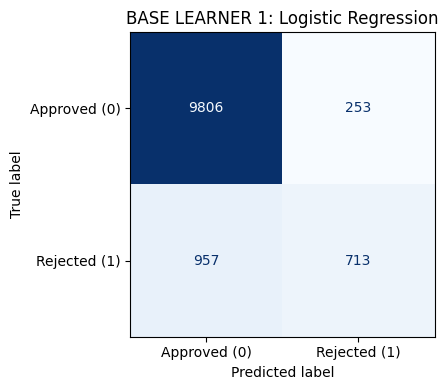

In [4]:
# confusion matrix for Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['Approved (0)', 'Rejected (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('BASE LEARNER 1: Logistic Regression')
plt.tight_layout()
plt.savefig('cm_lr_base.png', dpi=150)
plt.show()

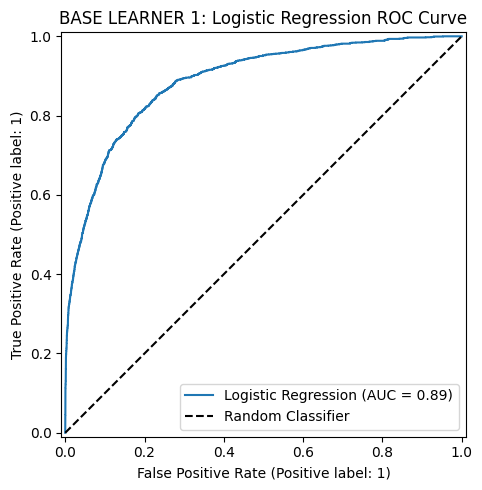

In [5]:
# ROC curve for Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=ax, name='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('BASE LEARNER 1: Logistic Regression ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('roc_lr_base.png', dpi=150)
plt.show()

**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Train and evaluate BASE LEARNER 2 - K-Nearest Neighbours

In [6]:
# create and train KNN (BASE LEARNER 2)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_sc, y_train)

# generate predictions
y_pred_knn = knn_model.predict(X_test_sc)
y_prob_knn = knn_model.predict_proba(X_test_sc)[:, 1]

print('=== BASE LEARNER 2: K-Nearest Neighbours (K=5) ===')
print(classification_report(y_test, y_pred_knn, target_names=['Approved (0)', 'Rejected (1)']))

# calculate metrics
knn_accuracy  = accuracy_score(y_test, y_pred_knn)
knn_recall    = recall_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_f1        = f1_score(y_test, y_pred_knn)
knn_auc       = roc_auc_score(y_test, y_prob_knn)

print(f'Accuracy:  {knn_accuracy:.4f}')
print(f'Recall:    {knn_recall:.4f}')
print(f'Precision: {knn_precision:.4f}')
print(f'F1-Score:  {knn_f1:.4f}')
print(f'AUC-ROC:   {knn_auc:.4f}')

=== BASE LEARNER 2: K-Nearest Neighbours (K=5) ===
              precision    recall  f1-score   support

Approved (0)       0.93      0.98      0.95     10059
Rejected (1)       0.82      0.55      0.65      1670

    accuracy                           0.92     11729
   macro avg       0.87      0.76      0.80     11729
weighted avg       0.91      0.92      0.91     11729

Accuracy:  0.9177
Recall:    0.5461
Precision: 0.8150
F1-Score:  0.6540
AUC-ROC:   0.8633


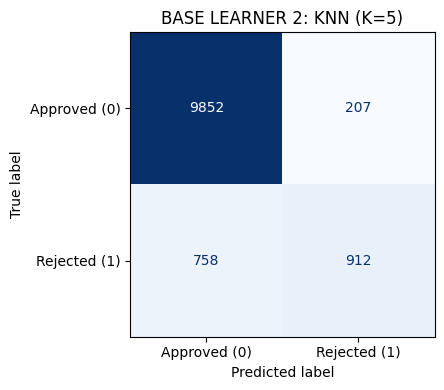

In [7]:
# confusion matrix for KNN
fig, ax = plt.subplots(figsize=(5, 4))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                               display_labels=['Approved (0)', 'Rejected (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('BASE LEARNER 2: KNN (K=5)')
plt.tight_layout()
plt.savefig('cm_knn_base.png', dpi=150)
plt.show()

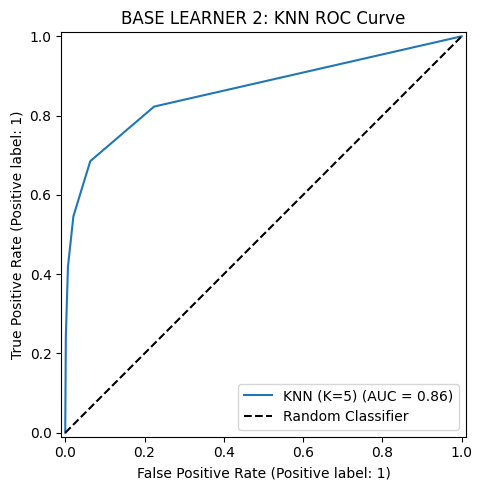

In [8]:
# ROC curve for KNN
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_knn, ax=ax, name='KNN (K=5)')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('BASE LEARNER 2: KNN ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('roc_knn_base.png', dpi=150)
plt.show()

**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Combine the TWO base learners into a probability-based Voting Ensemble Classifier

In [9]:
# create Voting Ensemble Classifier combining LR and KNN
# voting='soft' means probability-based voting (as required by coursework)
# this averages the predicted probabilities from both base learners
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    voting='soft'  # probability-based voting
)

# train the ensemble on scaled data
ensemble_model.fit(X_train_sc, y_train)

# generate predictions
y_pred_ensemble = ensemble_model.predict(X_test_sc)
y_prob_ensemble = ensemble_model.predict_proba(X_test_sc)[:, 1]

print('✅ Voting Ensemble Classifier trained successfully')
print('   Base Learners: Logistic Regression + KNN')
print('   Voting Type: Soft (probability-based)')

✅ Voting Ensemble Classifier trained successfully
   Base Learners: Logistic Regression + KNN
   Voting Type: Soft (probability-based)


In [10]:
# evaluate ensemble performance
print('=== VOTING ENSEMBLE CLASSIFIER (LR + KNN) ===')
print(classification_report(y_test, y_pred_ensemble, target_names=['Approved (0)', 'Rejected (1)']))

# calculate metrics
ensemble_accuracy  = accuracy_score(y_test, y_pred_ensemble)
ensemble_recall    = recall_score(y_test, y_pred_ensemble)
ensemble_precision = precision_score(y_test, y_pred_ensemble)
ensemble_f1        = f1_score(y_test, y_pred_ensemble)
ensemble_auc       = roc_auc_score(y_test, y_prob_ensemble)

print(f'Accuracy:  {ensemble_accuracy:.4f}')
print(f'Recall:    {ensemble_recall:.4f}')
print(f'Precision: {ensemble_precision:.4f}')
print(f'F1-Score:  {ensemble_f1:.4f}')
print(f'AUC-ROC:   {ensemble_auc:.4f}')

=== VOTING ENSEMBLE CLASSIFIER (LR + KNN) ===
              precision    recall  f1-score   support

Approved (0)       0.92      0.99      0.95     10059
Rejected (1)       0.86      0.51      0.64      1670

    accuracy                           0.92     11729
   macro avg       0.89      0.75      0.80     11729
weighted avg       0.91      0.92      0.91     11729

Accuracy:  0.9183
Recall:    0.5108
Precision: 0.8581
F1-Score:  0.6404
AUC-ROC:   0.9105


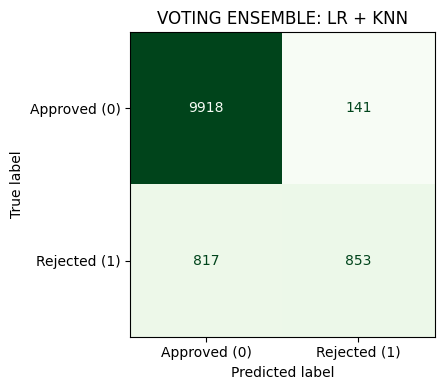

In [11]:
# confusion matrix for Voting Ensemble
fig, ax = plt.subplots(figsize=(5, 4))
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ensemble,
                               display_labels=['Approved (0)', 'Rejected (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('VOTING ENSEMBLE: LR + KNN')
plt.tight_layout()
plt.savefig('cm_ensemble.png', dpi=150)
plt.show()

**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Compare ensemble performance against individual base learners

In [12]:
# create comparison table
comparison = pd.DataFrame({
    'Model': ['LR (Base Learner 1)', 'KNN (Base Learner 2)', 'Voting Ensemble (LR+KNN)'],
    'Accuracy':  [lr_accuracy,  knn_accuracy,  ensemble_accuracy],
    'Recall':    [lr_recall,    knn_recall,    ensemble_recall],
    'Precision': [lr_precision, knn_precision, ensemble_precision],
    'F1-Score':  [lr_f1,        knn_f1,        ensemble_f1],
    'AUC-ROC':   [lr_auc,       knn_auc,       ensemble_auc]
}).round(4)

print('=== Base Learners vs. Voting Ensemble Comparison ===')
print(comparison.to_string(index=False))

# check if ensemble improved
print(f'\n--- Ensemble Improvement Analysis ---')
print(f'Ensemble vs LR:  Accuracy {ensemble_accuracy-lr_accuracy:+.4f}, F1 {ensemble_f1-lr_f1:+.4f}')
print(f'Ensemble vs KNN: Accuracy {ensemble_accuracy-knn_accuracy:+.4f}, F1 {ensemble_f1-knn_f1:+.4f}')

=== Base Learners vs. Voting Ensemble Comparison ===
                   Model  Accuracy  Recall  Precision  F1-Score  AUC-ROC
     LR (Base Learner 1)    0.8968  0.4269     0.7381    0.5410   0.8885
    KNN (Base Learner 2)    0.9177  0.5461     0.8150    0.6540   0.8633
Voting Ensemble (LR+KNN)    0.9183  0.5108     0.8581    0.6404   0.9105

--- Ensemble Improvement Analysis ---
Ensemble vs LR:  Accuracy +0.0215, F1 +0.0994
Ensemble vs KNN: Accuracy +0.0006, F1 -0.0136


---

## PART 2: REGRESSION DECISION TREES FOR MAXIMUM LOAN AMOUNT

**Requirement:** Build TWO decision tree regression models:
- **DT-1:** Fully grown (no constraints)
- **DT-2:** Pruned to FOUR levels only (max_depth=4)

**Metrics Required:** MSE, MAE, R²

---

**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Load Dataset B (Regression) for maximum loan amount prediction

In [13]:
# load Dataset B — contains only approved loans
df_regression = pd.read_csv('Dataset_B_Regression.csv')

# separate features and target
X_reg = df_regression.drop(columns=['max_allowed_loan'])
y_reg = df_regression['max_allowed_loan']

# create bins from the continuous target so the train-test split keeps a similar
# target-value distribution in both subsets (stratification for regression)
strat_bins = pd.qcut(y_reg, q=5, duplicates='drop')

# perform train-test split with stratification based on the binned target
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42, stratify=strat_bins)

print(f'Dataset B loaded: {df_regression.shape}')
print(f'Training set: {X_train_reg.shape[0]} rows')
print(f'Test set:     {X_test_reg.shape[0]} rows')
print(f'\nTarget variable statistics:')
print(y_reg.describe())

Dataset B loaded: (50292, 19)
Training set: 40233 rows
Test set:     10059 rows

Target variable statistics:
count    5.029200e+04
mean     8.139253e+04
std      5.812145e+04
min      2.320000e+02
25%      4.911050e+04
50%      6.943150e+04
75%      9.899100e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Build DT-1 (Fully Grown Decision Tree Regressor)

In [14]:
# DT-1: Fully grown decision tree (no constraints)
dt1_fully_grown = DecisionTreeRegressor(random_state=42)

# train DT-1
dt1_fully_grown.fit(X_train_reg, y_train_reg)

# generate predictions
y_pred_dt1 = dt1_fully_grown.predict(X_test_reg)

print('✅ DT-1 (Fully Grown) trained successfully')
print(f'   Tree Depth: {dt1_fully_grown.get_depth()}')
print(f'   Number of Leaves: {dt1_fully_grown.get_n_leaves()}')

✅ DT-1 (Fully Grown) trained successfully
   Tree Depth: 24
   Number of Leaves: 23041


In [15]:
# evaluate DT-1 using the THREE required metrics: MSE, MAE, R²
dt1_mse = mean_squared_error(y_test_reg, y_pred_dt1)
dt1_mae = mean_absolute_error(y_test_reg, y_pred_dt1)
dt1_r2  = r2_score(y_test_reg, y_pred_dt1)

print('=== DT-1 (Fully Grown) — Test Performance ===')
print(f'MSE:      £{dt1_mse:,.2f}')
print(f'MAE:      £{dt1_mae:,.2f}')
print(f'R-Square: {dt1_r2:.4f}')

=== DT-1 (Fully Grown) — Test Performance ===
MSE:      £1,623,035,891.58
MAE:      £2,712.92
R-Square: 0.5309


**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Build DT-2 (Pruned to FOUR levels only)

In [16]:
# DT-2: Pruned decision tree to FOUR levels only (max_depth=4)
# as per coursework requirement: "pruned to FOUR levels Only"
dt2_pruned = DecisionTreeRegressor(max_depth=4, random_state=42)

# train DT-2
dt2_pruned.fit(X_train_reg, y_train_reg)

# generate predictions
y_pred_dt2 = dt2_pruned.predict(X_test_reg)

print('✅ DT-2 (Pruned to 4 Levels) trained successfully')
print(f'   Tree Depth: {dt2_pruned.get_depth()}')
print(f'   Number of Leaves: {dt2_pruned.get_n_leaves()}')

✅ DT-2 (Pruned to 4 Levels) trained successfully
   Tree Depth: 4
   Number of Leaves: 16


In [17]:
# evaluate DT-2 using the THREE required metrics: MSE, MAE, R²
dt2_mse = mean_squared_error(y_test_reg, y_pred_dt2)
dt2_mae = mean_absolute_error(y_test_reg, y_pred_dt2)
dt2_r2  = r2_score(y_test_reg, y_pred_dt2)

print('=== DT-2 (Pruned to 4 Levels) — Test Performance ===')
print(f'MSE:      £{dt2_mse:,.2f}')
print(f'MAE:      £{dt2_mae:,.2f}')
print(f'R-Square: {dt2_r2:.4f}')

=== DT-2 (Pruned to 4 Levels) — Test Performance ===
MSE:      £1,479,060,549.39
MAE:      £12,047.10
R-Square: 0.5725


**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Compare DT-1 vs DT-2 performance using required metrics

In [18]:
# create comparison table (using EXACTLY the metrics required by coursework)
metrics_comparison = pd.DataFrame({
    'Metric': ['MSE (£)', 'MAE (£)', 'R-Square'],
    'DT-1 (Fully Grown)': [
        f'{dt1_mse:,.2f}',
        f'{dt1_mae:,.2f}',
        f'{dt1_r2:.4f}'
    ],
    'DT-2 (Pruned to 4 Levels)': [
        f'{dt2_mse:,.2f}',
        f'{dt2_mae:,.2f}',
        f'{dt2_r2:.4f}'
    ]
})

print('=== DT-1 vs DT-2 Performance Comparison ===')
print(metrics_comparison.to_string(index=False))

=== DT-1 vs DT-2 Performance Comparison ===
  Metric DT-1 (Fully Grown) DT-2 (Pruned to 4 Levels)
 MSE (£)   1,623,035,891.58          1,479,060,549.39
 MAE (£)           2,712.92                 12,047.10
R-Square             0.5309                    0.5725


**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Visualize DT-1 (Fully Grown) tree structure

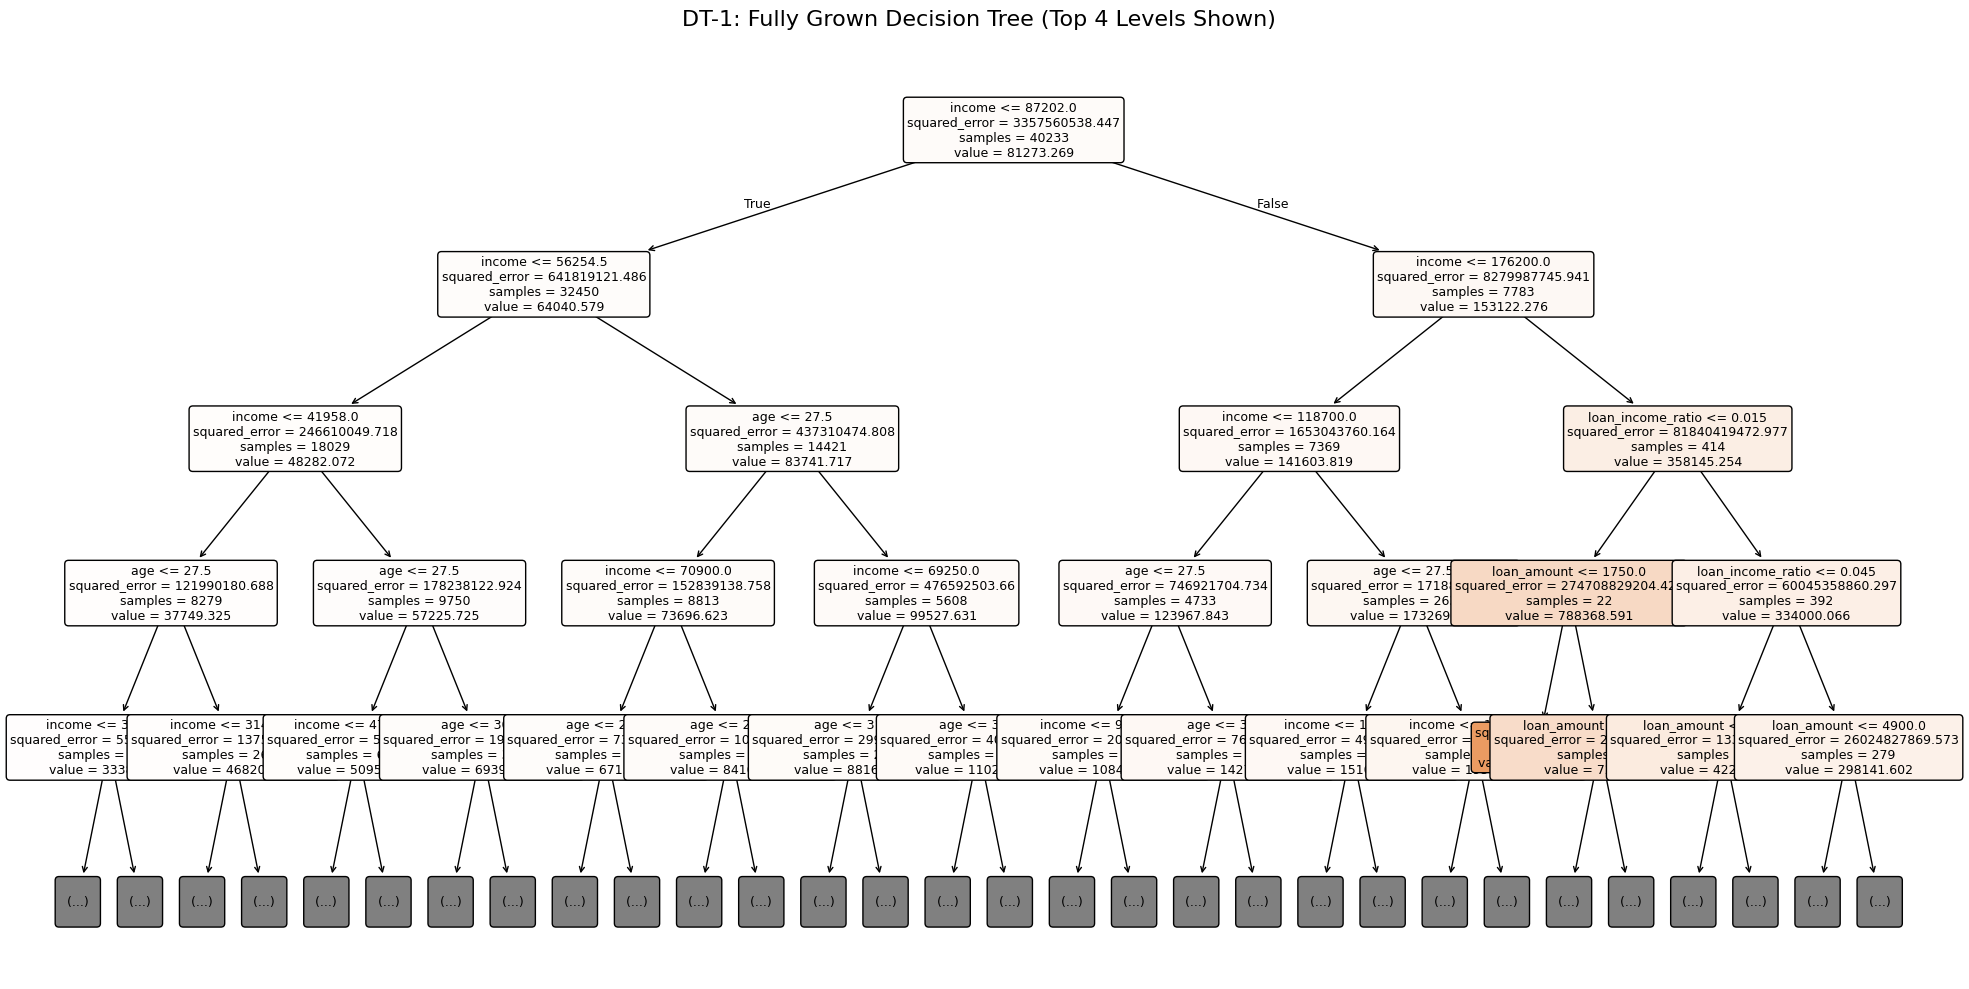

✅ Saved: dt1_fully_grown.png


In [19]:
# visualize DT-1 (showing top 4 levels for readability)
# the actual tree is fully grown but we show only top levels in visualization
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt1_fully_grown,
          max_depth=4,  # show top 4 levels for readability
          feature_names=X_reg.columns,
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
ax.set_title('DT-1: Fully Grown Decision Tree (Top 4 Levels Shown)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('dt1_fully_grown.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: dt1_fully_grown.png')

**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Visualize DT-2 (Pruned to 4 Levels) tree structure

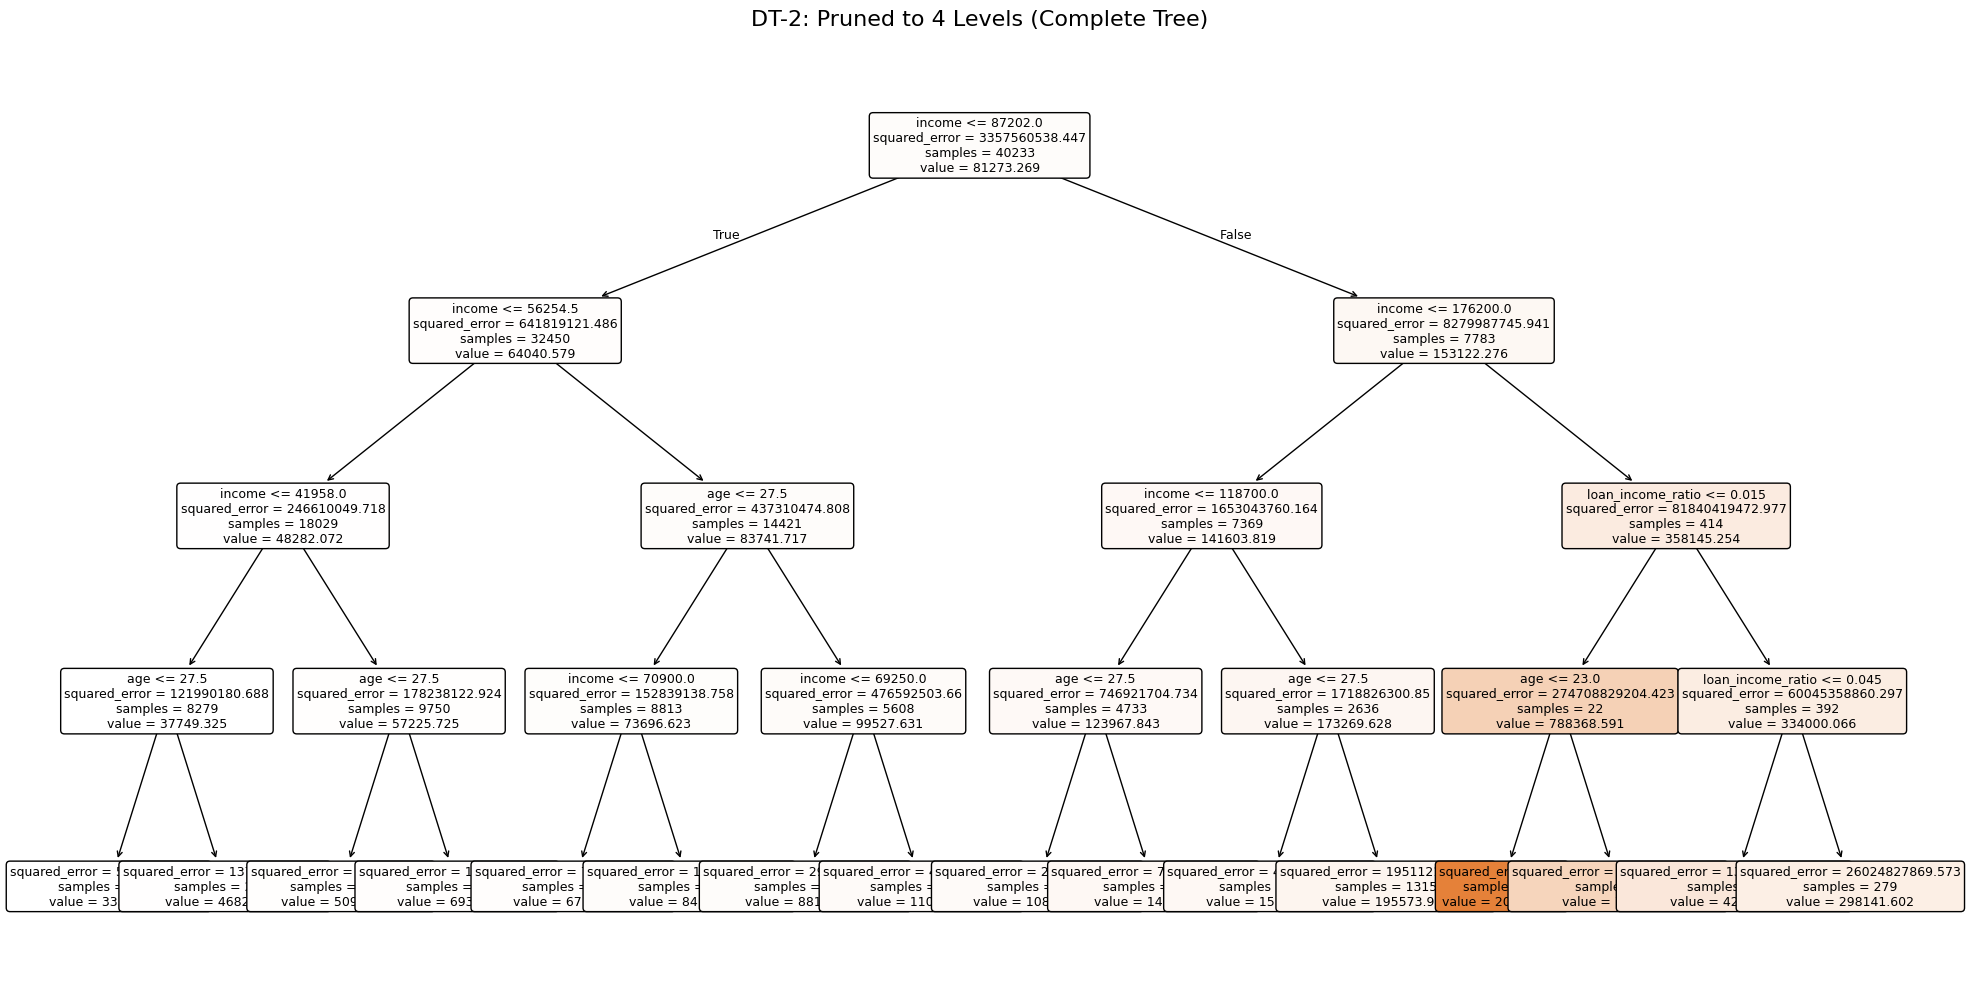

✅ Saved: dt2_pruned_4_levels.png


In [20]:
# visualize DT-2 (shows ALL 4 levels since tree is limited to 4)
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt2_pruned,
          feature_names=X_reg.columns,
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
ax.set_title('DT-2: Pruned to 4 Levels (Complete Tree)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('dt2_pruned_4_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: dt2_pruned_4_levels.png')

**Code Source Citation**

* **Session:** Code Reuse Session 3 — Seminar Sessions
* **Purpose:** Predict maximum loan amount for Client 60256 (Case Study B)

In [21]:
# Case Study B: Client 60256 prediction
# create feature vector for Client 60256
client_60256 = pd.DataFrame({
    'age': [56.0],
    'income': [57000],
    'employment_length': [15],
    'loan_amount': [25700],
    'loan_interest_rate': [23.0],
    'loan_income_ratio': [0.10],
    'payment_default_on_file': [0],
    'credit_history_length': [35],
    'home_ownership_MORTGAGE': [0],
    'home_ownership_OTHER': [0],
    'home_ownership_OWN': [0],
    'home_ownership_RENT': [1],
    'loan_intent_DEBTCONSOLIDATION': [0],
    'loan_intent_EDUCATION': [0],
    'loan_intent_HOMEIMPROVEMENT': [0],
    'loan_intent_MEDICAL': [1],
    'loan_intent_PERSONAL': [0],
    'loan_intent_VENTURE': [0]
})

# predict using both models
pred_dt1 = dt1_fully_grown.predict(client_60256)[0]
pred_dt2 = dt2_pruned.predict(client_60256)[0]

print('=== Case Study B: Client 60256 Prediction ===')
print('Client Profile:')
print('  - Age: 56 years')
print('  - Income: £57,000')
print('  - Loan Requested: £25,700')
print('  - Intent: Medical')
print('  - Status: Approved')
print(f'\nPredicted Maximum Loan Amount:')
print(f'  - DT-1 (Fully Grown): £{pred_dt1:,.2f}')
print(f'  - DT-2 (Pruned):      £{pred_dt2:,.2f}')

=== Case Study B: Client 60256 Prediction ===
Client Profile:
  - Age: 56 years
  - Income: £57,000
  - Loan Requested: £25,700
  - Intent: Medical
  - Status: Approved

Predicted Maximum Loan Amount:
  - DT-1 (Fully Grown): £87,430.00
  - DT-2 (Pruned):      £88,160.66
